In [44]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [45]:
# Прочитайте данные (переменную назовите 'df')
df = pd.read_csv('data.csv')

# Вывести несколько первых строк таблицы данных
print(df.head())

         Дата  Склад Контрагент Номенклатура  Количество
0  2018-01-04      1  address_0    product_0           4
1  2018-01-04      1  address_0    product_1           4
2  2018-01-04      1  address_0    product_2           5
3  2018-01-04      1  address_0    product_3          10
4  2018-01-04      1  address_0    product_4           2


Проверяем формат столбцов

In [46]:
df.dtypes

Дата            object
Склад            int64
Контрагент      object
Номенклатура    object
Количество       int64
dtype: object

Сразу переведем столбец "Дата" в правильный формат

In [47]:
df['Дата'] = pd.to_datetime(df['Дата'])

Сгруппируйте данные по дате, посчитайте количество продаж

In [48]:
grouped_df = df.groupby('Дата', as_index=False)['Количество'].sum()

Вывести несколько первых строк сгруппированных данных

In [49]:
grouped_df.head()

,Дата,Количество
0,2018-01-04,3734
1,2018-01-05,3643
2,2018-01-06,3193
3,2018-01-07,3298
4,2018-01-09,4055


Нарисуйте график продаж у `grouped_df`

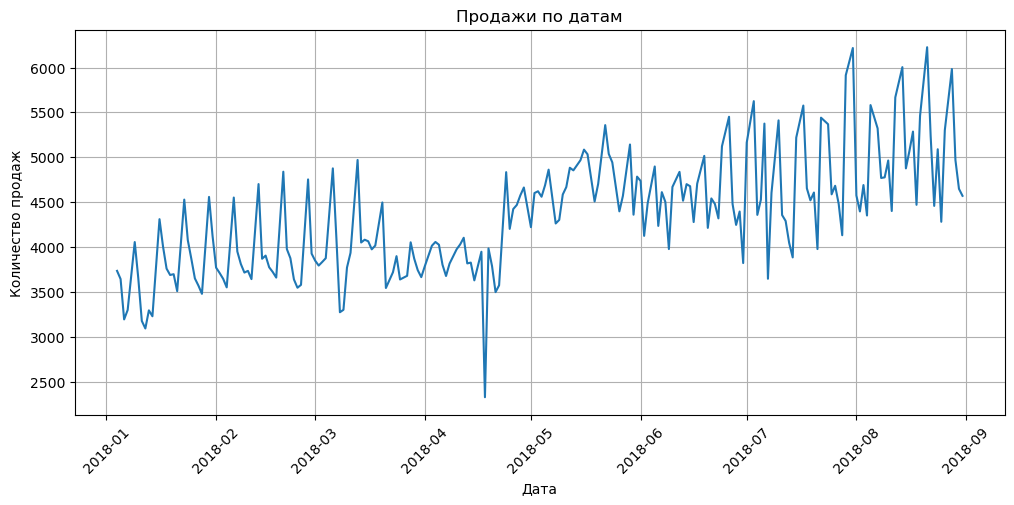

In [50]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))
plt.plot(grouped_df['Дата'], grouped_df['Количество'])

plt.title('Продажи по датам')
plt.xlabel('Дата')
plt.ylabel('Количество продаж')
plt.xticks(rotation=45)
plt.grid()
plt.show()

Опишите что вы видите на графике. Ваша задача - максимально описать график

In [51]:
# На графике показано количество продаж по датам за период примерно с января по сентябрь 2018 года.

# По оси X расположена дата, а по оси Y — количество продаж. Значения количества продаж находятся примерно в диапазоне от 2500 до 6000.

# В начале года, в январе, количество продаж в основном находится примерно на уровне 3500–4000, при этом показатель достаточно сильно колеблется.

# В феврале и марте продажи постепенно увеличиваются. Значения становятся выше и чаще достигают примерно 4000–4500 продаж. При этом график продолжает сильно колебаться: в некоторые дни продажи растут, а в другие заметно снижаются.

# В апреле наблюдается снижение продаж. Особенно заметно сильное падение ближе к концу апреля — количество продаж опускается примерно до 2300–2500, что является одним из самых низких значений на графике.

# В мае ситуация резко меняется: продажи снова увеличиваются и поднимаются примерно до 4000–4500. После этого в июне продажи остаются на достаточно высоком уровне, в среднем около 4000–4700, но также наблюдаются резкие скачки вверх и вниз.

# В июле количество продаж продолжает колебаться. В некоторые дни показатель поднимается примерно до 5000, но иногда снова снижается до 3500–4000.

# В августе и сентябре продажи в целом становятся выше. На графике появляется больше значений около 4500–5000, а некоторые пики доходят примерно до 5800–6000 продаж. Это самые высокие значения за весь рассматриваемый период.

# Общий вывод

# В целом можно сказать, что продажи имеют тенденцию к росту в течение года, хотя график очень нестабильный и количество продаж сильно меняется от даты к дате. В начале года продажи находятся примерно на уровне 3500–4000, в апреле происходит заметное падение, а начиная с мая продажи снова растут. Самые высокие показатели наблюдаются в августе–сентябре, а самый заметный минимум — в конце апреля.

Найдите строку, у которой максимальный выброс по количеству продаж (нужно найти выброс у `df`)

In [52]:
df.loc[df['Количество'].idxmax()]

Дата            2018-06-28 00:00:00
Склад                             1
Контрагент              address_208
Номенклатура              product_0
Количество                      200
Name: 218822, dtype: object

Найдите топовый товар по продажам по средам за июнь, июль, август у 3 склада

In [53]:
df["Дата"] = pd.to_datetime(df["Дата"])

filtered_df = df[
    (df["Дата"].dt.dayofweek == 2) &
    (df["Дата"].dt.month.isin([6, 7, 8])) &
    (df["Склад"].isin([1, 2, 3]))
]

top_product = (
    filtered_df.groupby("Номенклатура", as_index=False)
    .agg(Количество=("Количество", "sum"))
    .sort_values("Количество", ascending=False)
)

top_product.head(1)

,Номенклатура,Количество
1,product_1,8135


In [54]:
grouped_df["Дата"].min(), grouped_df["Дата"].max()

(Timestamp('2018-01-04 00:00:00'), Timestamp('2018-08-31 00:00:00'))

Скачайте данные по погоде с https://rp5.ru/Архив_погоды_в_Астане (скачайте исходные данные, и далее преобразуйте так, чтобы мы имели Дату и Среднюю температуру за день), объедините таблицу температуры с `grouped_df`, и нарисуйте график `y=['Количество продаж', 'T']`, где Т это температура. А также отдельно график температуры.

In [55]:
import gzip

path = r"C:\Users\admin\nanapython\35188.04.01.2018.31.08.2018.1.0.0.ru.utf8.00000000.csv.gz"

with gzip.open(path, "rt", encoding="utf-8", errors="replace") as f:
    for i in range(15):
        print(i, repr(f.readline()))

0 '# Метеостанция Астана, Казахстан, WMO_ID=35188, выборка с 04.01.2018 по 31.08.2018, все дни\n'
1 '# Кодировка: UTF-8\n'
2 '# Информация предоставлена сайтом "Расписание Погоды", rp5.ru\n'
3 '# Пожалуйста, при использовании данных, любезно указывайте названный сайт.\n'
4 '# Обозначения метеопараметров см. по адресу http://rp5.ru/archive.php?wmo_id=35188&lang=ru\n'
5 '#\n'
6 '"Местное время в Астане";"T";"Po";"P";"Pa";"U";"DD";"Ff";"ff10";"ff3";"N";"WW";"W1";"W2";"Tn";"Tx";"Cl";"Nh";"H";"Cm";"Ch";"VV";"Td";"RRR";"tR";"E";"Tg";"E\'";"sss"\n'
7 '"31.08.2018 23:00";"8.2";"736.6";"768.3";"0.2";"78";"Ветер, дующий с северо-востока";"4";"";"";"70 – 80%.";"Состояние неба в общем не изменилось. ";"Ливень (ливни).";"Облака покрывали более половины неба в течение всего соответствующего периода.";"";"13.9";"Слоисто-кучевые, образовавшиеся не из кучевых.";"70 – 80%.";"1000-1500";"Высококучевых, высокослоистых или слоисто-дождевых облаков нет.";"Перистых, перисто-кучевых или перисто-слоистых нет."

In [56]:
import pandas as pd

path = r"C:\Users\admin\nanapython\35188.04.01.2018.31.08.2018.1.0.0.ru.utf8.00000000.csv.gz"

weather = pd.read_csv(
    path,
    compression="gzip",
    sep=";",
    skiprows=6,
    encoding="utf-8",
    quotechar='"'
)

print(weather.columns)
print(weather.head())

Index(['Местное время в Астане', 'T', 'Po', 'P', 'Pa', 'U', 'DD', 'Ff', 'ff10',
       'ff3', 'N', 'WW', 'W1', 'W2', 'Tn', 'Tx', 'Cl', 'Nh', 'H', 'Cm', 'Ch',
       'VV', 'Td', 'RRR', 'tR', 'E', 'Tg', 'E'', 'sss'],
      dtype='object')
                  Местное время в Астане      T     Po    P    Pa  \
31.08.2018 23:00                     8.2  736.6  768.3  0.2  78.0   
31.08.2018 20:00                     9.6  736.4  767.9  1.2  88.0   
31.08.2018 17:00                    11.3  735.2  766.4  0.4  83.0   
31.08.2018 14:00                    12.3  734.8  765.9  0.9  80.0   
31.08.2018 11:00                    13.2  733.9  764.8  1.0  83.0   

                                                       U  DD  Ff  ff10  \
31.08.2018 23:00          Ветер, дующий с северо-востока   4 NaN   NaN   
31.08.2018 20:00    Ветер, дующий с западо-северо-запада   3 NaN   NaN   
31.08.2018 17:00  Ветер, дующий с востоко-северо-востока   4 NaN   NaN   
31.08.2018 14:00          Ветер, дующий с северо-вос

In [57]:
weather.columns

Index(['Местное время в Астане', 'T', 'Po', 'P', 'Pa', 'U', 'DD', 'Ff', 'ff10',
       'ff3', 'N', 'WW', 'W1', 'W2', 'Tn', 'Tx', 'Cl', 'Nh', 'H', 'Cm', 'Ch',
       'VV', 'Td', 'RRR', 'tR', 'E', 'Tg', 'E'', 'sss'],
      dtype='object')

        Дата        T
0 2018-01-04 -14.0750
1 2018-01-05 -16.8625
2 2018-01-06 -13.3000
3 2018-01-07 -12.7500
4 2018-01-08 -15.4125
        Дата  Количество        T
0 2018-01-04        3734 -14.0750
1 2018-01-05        3643 -16.8625
2 2018-01-06        3193 -13.3000
3 2018-01-07        3298 -12.7500
4 2018-01-09        4055  -6.2500
Index(['Дата', 'Количество', 'T'], dtype='object')


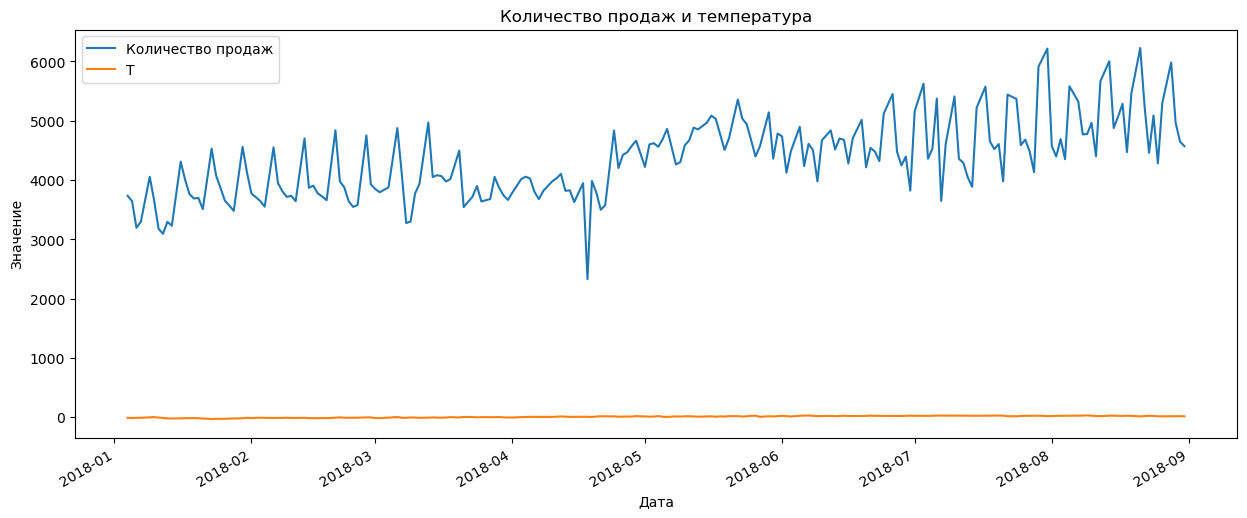

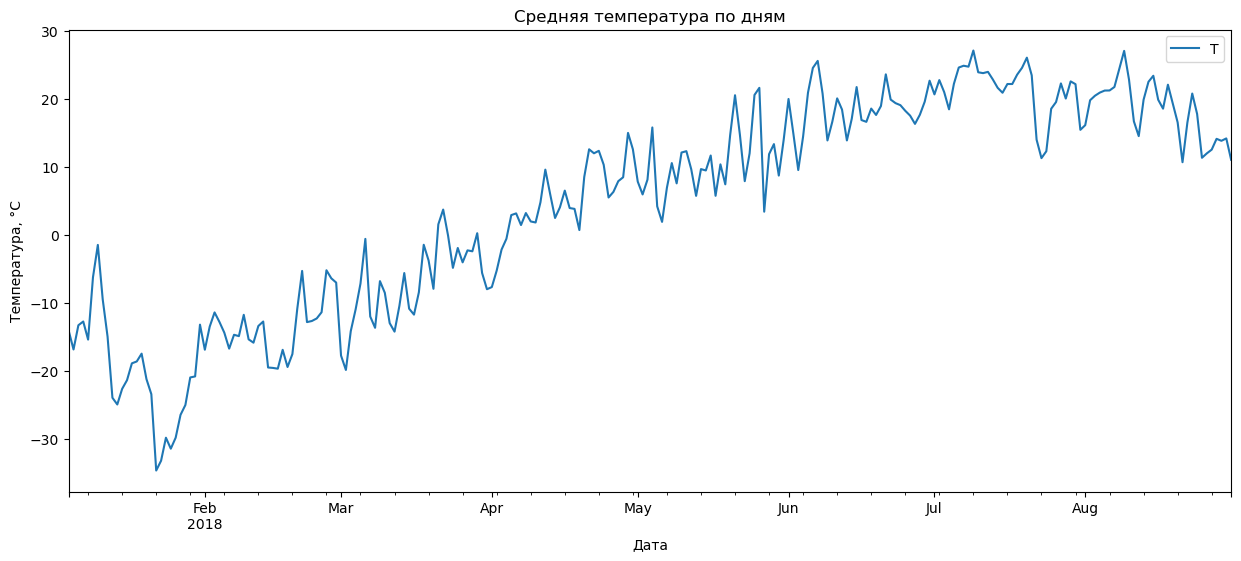

In [58]:
import pandas as pd
import matplotlib.pyplot as plt

path = r"C:\Users\admin\nanapython\35188.04.01.2018.31.08.2018.1.0.0.ru.utf8.00000000.csv.gz"

weather = pd.read_csv(
    path,
    compression="gzip",
    sep=";",
    skiprows=7,
    header=None,
    usecols=[0, 1],
    names=["Дата", "T"],
    encoding="utf-8"


weather["Дата"] = pd.to_datetime(
    weather["Дата"],
    format="%d.%m.%Y %H:%M"
).dt.normalize()

weather["T"] = pd.to_numeric(
    weather["T"],
    errors="coerce"
)


weather_daily = (
    weather.groupby("Дата", as_index=False)
    .agg(T=("T", "mean"))
)

print(weather_daily.head())



grouped_df = grouped_df.merge(
    weather_daily,
    on="Дата",
    how="left"
)


print(grouped_df.head())
print(grouped_df.columns)




if "Количество" in grouped_df.columns:
    grouped_df = grouped_df.rename(
        columns={"Количество": "Количество продаж"}
    )




grouped_df.plot(
    x="Дата",
    y=["Количество продаж", "T"],
    figsize=(15, 6)
)

plt.title("Количество продаж и температура")
plt.xlabel("Дата")
plt.ylabel("Значение")
plt.show()


weather_daily.plot(
    x="Дата",
    y="T",
    figsize=(15, 6)
)

plt.title("Средняя температура по дням")
plt.xlabel("Дата")
plt.ylabel("Температура, °C")
plt.show()